In [134]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors
import geopandas as gpd
from shapely.geometry import Polygon, Point

from unidecode import unidecode

In [135]:
# parameters
region_level = "nuts4"
industry_level = "nace3d"
year = 2017

**R1.1 -- co-located supplier patterns**

In [136]:
# matrix 1 -- supplier ties inside regions (co-location) between firms in SR and not SR industries
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf["nr_io_no_sr_ties"] = ddf["nr_io_ties"] - ddf["nr_io_sr_ties"]

# sum up ties, where distance > 0 (aka not the same region)
dist_0_row = ddf[ddf["dist_int"] == 0]
dist_0_row["colocation"] = 1
dist_above_0_rows = ddf[ddf["dist_int"] > 0]
summed_row = dist_above_0_rows.sum(numeric_only=True)
summed_row["colocation"] = 0

# combine
inreg = pd.concat([dist_0_row, pd.DataFrame([summed_row])], ignore_index=True)
inreg = inreg[["colocation", "nr_io_sr_ties", "nr_io_no_sr_ties"]]

# clean
inreg["colocation"] = inreg["colocation"].astype(int)
inreg.sort_values(by="colocation", ascending=True, inplace=True)
inreg.set_index("colocation", inplace=True)
inreg.columns = [1, 0]
inreg.columns.name = "sr01"
inreg = inreg.T.sort_values(by="sr01", ascending=False)
inreg_mat = (inreg / inreg.sum().sum())

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_58357/2776775428.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dist_0_row["colocation"] = 1


In [137]:
inreg_mat

colocation,0,1
sr01,,
1,0.459349,0.100769
0,0.368890,0.070993


In [138]:
# matrix 2 -- supplier ties between firms in industries that tend to co-locate in SR or not SR industries

# firm-to-firm supplier table
ff_table = pd.read_csv(f"../data/oc17_2024_febr2/indind_dist_{industry_level}_{year}.csv", sep=";")

# SR and coagglomeration table
ii_table = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_level}_{year}.csv", sep=";")

# binary industry-industry variable -- here I can switch to other measures
def ind_ind_variables(df, colocation_variable):
    """function to speed up test with different coagglomeration measures"""
    df["sr01"] = (df["sr_norm"] > 0).astype(int)
    df["colocation_median01"] = (df[colocation_variable] > df[colocation_variable].median()).astype(int)
    return df
ii_table = ind_ind_variables(ii_table, colocation_variable="coagg_porter_rca01")

# make a clean matrix
ff_mat = pd.pivot_table(ff_cross,
        values="nr_ties_io",
        index="sr01",
        columns="colocation_median01",
        aggfunc="sum",
        margins=False)

ff_mat_norm = ff_mat / ff_mat.sum().sum()
ff_mat_norm.sort_values(by="sr01", ascending=False, inplace=True)

In [139]:
ff_mat_norm

colocation_median01,0,1
sr01,,
1,0.092568,0.431887
0,0.227672,0.247872


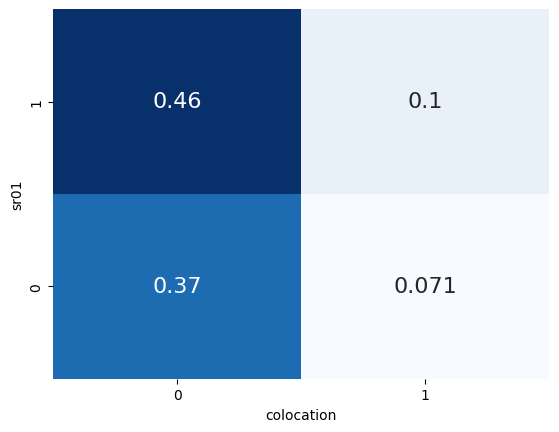

In [140]:
def crosstab_visual(mat, fontsize, colormap, ax=None):
    if ax is None:
        ax = plt.gca()
    mh = sns.heatmap(
        mat,
        annot=True,
        annot_kws={"fontsize":(fontsize)},
        cbar=False,
        cmap=colormap,
        ax=ax
    )

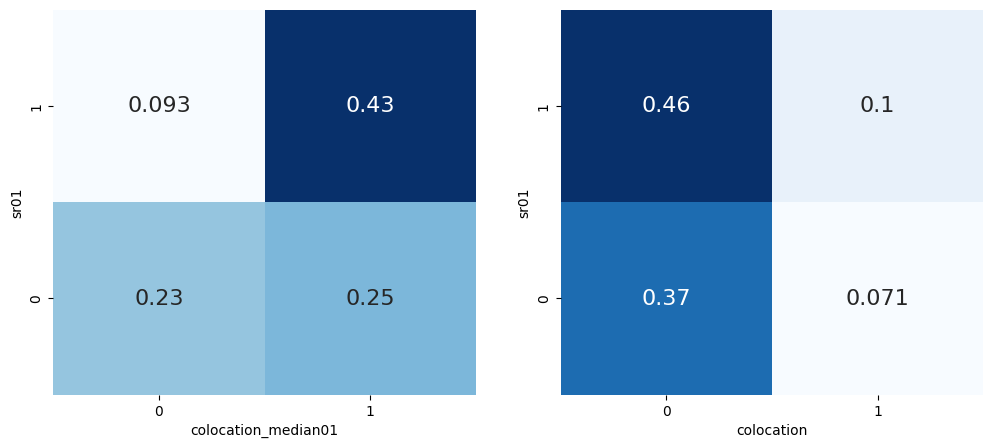

In [145]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
fontsize = 16

crosstab_visual(ff_mat_norm, fontsize=fontsize, colormap="Blues", ax=ax[0])

crosstab_visual(inreg_mat, fontsize=fontsize, colormap="Blues", ax=ax[1])

**R1.6 and R1.10 -- co-patenting and patent citations**

In [ ]:
# 


**interplots including citation data**

In [4]:
# data from /code/95b_regressions_main.R
mf_df = pd.read_csv("../outputs/marginal_effects_for_interplots_with_citations.csv", sep=";")

In [5]:
def custom_interplot(df, setting_vector, fontsize, ax=None):
    df = df[(df["dep_var"]==setting_vector[0]) & (df["y_values"]==setting_vector[1]) & (df["x_var"]==setting_vector[2])]
    
    if ax is None: 
        ax = plt.gca()
    ax.plot(df["x_values"], df["AME"], color="black", zorder=4)
    ax.plot(df["x_values"], df["upper"], color="#15636A", zorder=4)
    ax.plot(df["x_values"], df["lower"], color="#15636A", zorder=4)
    ax.fill_between(df["x_values"], df["lower"], df["upper"], color="#15636A", alpha=0.3, zorder=3)
    ax.axhline(y=0, color='black', linestyle='--', zorder=2)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

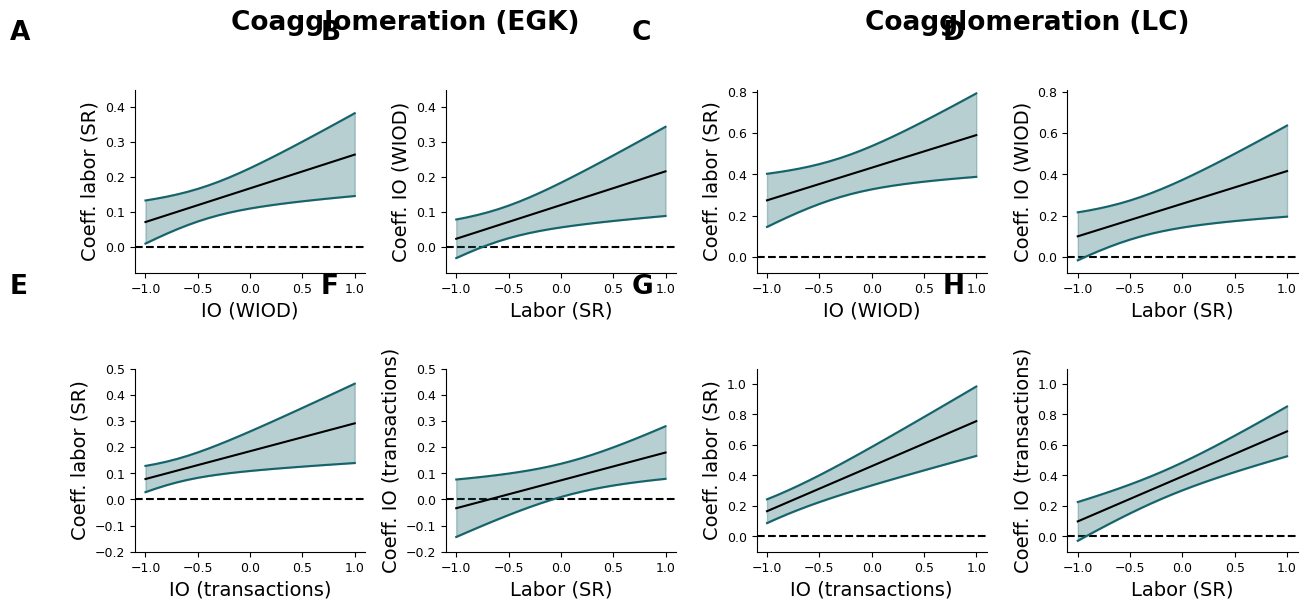

In [7]:
fig, ax = plt.subplots(2,4, figsize=(15, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.525)
fontsize=14


title_text = "Coagglomeration (EGK)"
fig.text((ax[0, 0].get_position().x0 + ax[0, 1].get_position().x1) / 2, 
         ax[0, 0].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)
title_text = "Coagglomeration (LC)"
fig.text((ax[0, 2].get_position().x0 + ax[0, 3].get_position().x1) / 2, 
         ax[0, 2].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,0])
ax[0,0].set_ylim(-0.075, 0.45)
ax[0,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,0].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,1])
ax[0,1].set_ylim(-0.075, 0.45)
ax[0,1].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,0])
ax[1,0].set_ylim(-0.2, 0.5)
ax[1,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,0].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,1])
ax[1,1].set_ylim(-0.2, 0.5)
ax[1,1].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,2])
ax[0,2].set_ylim(-0.075, 0.81)
ax[0,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,2].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,3])
ax[0,3].set_ylim(-0.075, 0.81)
ax[0,3].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,3].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,2])
ax[1,2].set_ylim(-0.1, 1.1)
ax[1,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,2].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,3])
ax[1,3].set_ylim(-0.1, 1.1)
ax[1,3].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,3].set_xlabel("Labor (SR)", size=fontsize)

ax[0,0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,3].annotate("D", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,0].annotate("E", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,1].annotate("F", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,2].annotate("G", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,3].annotate("H", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)

#plt.savefig(f"../figures/interplots_with_citation_controlled.png", dpi=300, bbox_inches='tight', facecolor="white")